In [1]:
import pickle
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Buka kembali datanya (Ini memastikan kita pakai data ori)
with open('../data/processed/data_splits_tfidf.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# 2. Cek sebentar untuk membuktikan ini data asli
print("Distribusi y_train asli:", np.bincount(y_train))

# 3. Latih Model
# Tambahkan C=0.1 untuk regularization (mencegah model bingung pada kata yang mirip)
model_lr_tuned = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
model_lr_tuned.fit(X_train, y_train)



c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Distribusi y_train asli: [53175 37909]


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Critical       0.94      0.81      0.87     13294
Non-Critical       0.77      0.93      0.84      9477

    accuracy                           0.86     22771
   macro avg       0.86      0.87      0.85     22771
weighted avg       0.87      0.86      0.86     22771



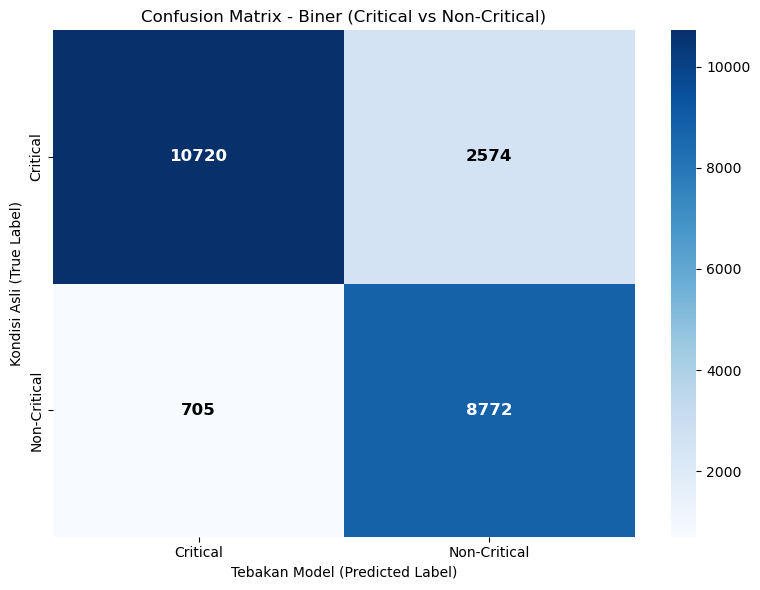

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Lakukan prediksi ulang
y_pred_baru = model_lr_tuned.predict(X_test)

# 2. Print Laporan Teks
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_baru, target_names=['Critical', 'Non-Critical']))

# 3. Gambar Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_baru)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Buat heatmap TANPA annot dulu
sns.heatmap(cm, 
            annot=False,
            fmt='d',
            cmap='Blues',
            xticklabels=['Critical', 'Non-Critical'],
            yticklabels=['Critical', 'Non-Critical'],
            ax=ax)

thresh = cm.max() / 2  # threshold untuk ganti warna teks

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thresh else "black"
        ax.text(j + 0.5, i + 0.5, 
                f'{cm[i, j]}',
                ha='center', va='center',
                color=color,
                fontsize=12, fontweight='bold')

ax.set_title('Confusion Matrix - Biner (Critical vs Non-Critical)')
ax.set_xlabel('Tebakan Model (Predicted Label)')
ax.set_ylabel('Kondisi Asli (True Label)')
plt.tight_layout()
plt.show()

In [3]:
import pickle

# Menyimpan model Logistic Regression
with open('../data/processed/model_lr_tuned_biner.pkl', 'wb') as f:
    pickle.dump(model_lr_tuned, f)

print("Model Logistic Regression berhasil disimpan untuk komparasi!")

Model Logistic Regression berhasil disimpan untuk komparasi!
